In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
TARGET = "dir_fwd_6h"
MARKET = "will-the-us-invade-iran-before-2027"

In [25]:
import pandas as pd
import sys, os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

sys.path.append(os.path.abspath("../src"))

from utils.wiki import (
    get_template_links,
    get_revision_diff,
    get_revisions,
    format_revisions,
    select_interesting_revisions,
    get_revisions_cached,
)
from utils.poly import get_event_slugs_paginated, get_price_series_from_slug
from utils.data_cleaning import validate_and_resample_panel
from utils.text import WIKI_STOP_WORDS
from utils.text.cleaning import (
    extract_added_text,
    remove_wiki_usernames,
    looks_like_username,
    contains_keywords,
)
from utils.text.tokenizer import spacy_tokenizer
from utils.text.nmf import build_text_nmf_features_safe

from targets import add_directional_targets
from lagging import add_exp_lag_features, add_rolling_sum

## Requesting Wiki Data

In [ ]:
# Capture edit metadata
titles = get_template_links("Template:Campaignbox 2026 Iran war")

all_revisions = []

for title in tqdm(titles):
    rev = get_revisions_cached(
        title,
        talk=True,
        start="2026-02-27",
        end="2026-06-01",
        include_diff=False,
    )

    if not rev.empty:
        all_revisions.append(rev)

wiki_df = pd.concat(all_revisions, ignore_index=True)

# Capture actual text diffs
interesting = select_interesting_revisions(wiki_df)

diff_rows = []

for _, row in tqdm(interesting.iterrows(), total=len(interesting)):
    parent_id = row["parentid"]
    rev_id = row["revid"]

    if pd.isna(parent_id) or pd.isna(rev_id) or parent_id == 0:
        diff_html = None
    else:
        try:
            diff_html = get_revision_diff(int(parent_id), int(rev_id))
        except Exception:
            diff_html = None

    diff_rows.append({
        "revid": rev_id,
        "parentid": parent_id,
        "diff_html": diff_html,
    })

diffs_df = pd.DataFrame(diff_rows)

wiki_with_diffs = wiki_df.merge(
    diffs_df,
    on=["revid", "parentid"],
    how="left",
)

wiki_with_diffs.to_parquet("data/wiki_with_selected_diffs.parquet")

## Load Wiki Data from Parquet

In [65]:
import pandas as pd

all_revisions = pd.read_parquet("data/wiki_with_selected_diffs.parquet")
print(all_revisions.shape)
all_revisions.head()

(9977, 15)


,revid,parentid,user,timestamp,size,comment,page_title,comment_len,has_reply,has_revert,size_change,temp,userhidden,commenthidden,diff_html
0,1342100916,1320762731,Web-julio,2026-03-07 00:25:36+00:00,42974,/* Change title to Iran-Israel war */ Reply,Talk:2024 Iran–Israel conflict,43,1,0,NaN,None,None,None,None
1,1342165207,1342100916,The Gnome,2026-03-07 11:44:09+00:00,43508,/* Change title to Iran-Israel war */,Talk:2024 Iran–Israel conflict,37,0,0,534.0,None,None,None,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li..."
2,1342182290,1342165207,Lova Falk,2026-03-07 14:37:44+00:00,43678,/* Change title to Iran-Israel war */ reply,Talk:2024 Iran–Israel conflict,43,1,0,170.0,None,None,None,None
3,1342488357,1342182290,The Gnome,2026-03-09 06:04:06+00:00,43680,/* Change title to Iran-Israel war */,Talk:2024 Iran–Israel conflict,37,0,0,2.0,None,None,None,None
4,1343060908,1342488357,Longhornsg,2026-03-12 01:27:13+00:00,44406,/* Merge proposal */ new section,Talk:2024 Iran–Israel conflict,32,0,0,726.0,None,None,None,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li..."


In [66]:


escalation_words = [
    "attack", "strike", "missile", "nuclear", "war", "bomb", "military"
]

uncertainty_words = [
    "report", "unconfirmed", "alleged", "rumor", "claim", "possible"
]

all_revisions["comment"] = all_revisions["comment"].fillna("")

all_revisions["has_escalation"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, escalation_words)
)

all_revisions["has_uncertainty"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, uncertainty_words)
)

all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False, regex=True).astype(int)

all_revisions["size_change"] = all_revisions.groupby("page_title")["size"].diff().abs()

all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    num_seen_before_global=("seen_before_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    avg_comment_len=("comment_len", "mean"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
    num_escalation_comments=("has_escalation", "sum"),
    num_uncertainty_comments=("has_uncertainty", "sum"),
    total_size_change=("size_change", "sum"),
    max_size_change=("size_change", "max"),
).reset_index().sort_values("timestamp")
print(features.shape)
features.head()


(1623, 13)


,timestamp,edits,unique_editors,new_editors,num_seen_before_global,total_comment_len,avg_comment_len,num_replies,num_reverts,num_escalation_comments,num_uncertainty_comments,total_size_change,max_size_change
0,2026-02-27 02:00:00+00:00,2,2,1,1,55,27.500000,0,0,0,0,183.0,183.0
1,2026-02-27 04:00:00+00:00,6,3,1,5,244,40.666667,2,0,0,0,723.0,491.0
2,2026-02-27 08:00:00+00:00,2,1,0,2,176,88.000000,0,0,0,0,1022.0,1022.0
3,2026-02-27 13:00:00+00:00,1,1,0,1,66,66.000000,1,0,0,0,0.0,NaN
4,2026-02-27 14:00:00+00:00,1,1,0,1,43,43.000000,1,0,0,0,278.0,278.0


In [87]:
market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=180,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    # market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    # market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 11/11 [01:06<00:00,  6.03s/it]


In [88]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(39918, 4)


,timestamp,price,market_slug,market_title
0,2025-12-28 22:00:19+00:00,0.125,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
1,2025-12-28 23:00:20+00:00,0.125,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
2,2025-12-29 00:00:39+00:00,0.125,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
3,2025-12-29 02:00:18+00:00,0.120,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
4,2025-12-29 03:00:34+00:00,0.120,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?


In [89]:
panel_clean = validate_and_resample_panel(panel_df, freq="1h")
panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])

In [90]:
# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.



prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

In [91]:
# 2. Pick feature columns BEFORE targets exist
# Exclude price because current price should be a separate control, not lagged automatically.
from lagging import add_time_lag_features


base_feature_cols = (
    df.select_dtypes(include=[np.number])
    .columns
    .drop(["price", "delta"], errors="ignore")
    .tolist()
)

# 3. Create backward-looking features only
# df = add_rolling_averages(df, base_feature_cols)
# df = add_exp_lag_features(df, base_feature_cols)
df = add_time_lag_features(df, base_feature_cols)
# df = add_rolling_sum(df, base_feature_cols)

# 4. Now create future-looking targets
df = add_directional_targets(df)

# 5. Choose X columns after targets are added
target_like = [
    c for c in df.columns
    if c.startswith(("price_fwd_", "ret_fwd_", "dir_fwd_", "future_volatility_"))
]

exclude_cols = ["price", "delta"] + target_like

X_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols
]

In [92]:
df.columns

Index(['timestamp', 'price', 'market_slug', 'market_title', 'delta', 'edits',
       'unique_editors', 'new_editors', 'num_seen_before_global',
       'total_comment_len', 'avg_comment_len', 'num_replies', 'num_reverts',
       'num_escalation_comments', 'num_uncertainty_comments',
       'total_size_change', 'max_size_change', 'price_fwd_1h', 'ret_fwd_1h',
       'dir_fwd_1h', 'future_volatility_1h', 'price_fwd_3h', 'ret_fwd_3h',
       'dir_fwd_3h', 'future_volatility_3h', 'price_fwd_6h', 'ret_fwd_6h',
       'dir_fwd_6h', 'future_volatility_6h', 'price_fwd_12h', 'ret_fwd_12h',
       'dir_fwd_12h', 'future_volatility_12h', 'price_fwd_24h', 'ret_fwd_24h',
       'dir_fwd_24h', 'future_volatility_24h'],
      dtype='object')

In [93]:
df = df.loc[:, ~df.columns.duplicated()].copy()
features_to_plot = [
    "edits_rolling_sum_6"
]
agg = (
    df.sort_values("timestamp")
      .groupby("timestamp")[features_to_plot + [TARGET]]
      .mean()
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

for feature in features_to_plot:
    ax1.plot(agg["timestamp"], agg[feature], label=feature, linewidth=1.5)

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Average wiki feature value")
ax1.set_yscale("log")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3, which="both")

ax2 = ax1.twinx()
ax2.plot(agg["timestamp"], agg[TARGET], label=TARGET, color="black", linewidth=2)
ax2.set_ylabel("Average price")
ax2.set_yscale("log")
ax2.legend(loc="upper right")

plt.title(f"Average Wiki Features and {TARGET} Over Time")
plt.tight_layout()
plt.show()

KeyError: "Columns not found: 'edits_rolling_sum_6'"

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [col + "_6h" for col in X_cols]

max_lag = 24
target_horizon = 6

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["price"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)
    avg_corr = corr_df.mean(axis=1)

    # NEGATIVE time axis
    time_to_event = -(np.arange(max_lag) + target_horizon)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

    # mark strongest signal
    best_idx = np.argmax(avg_corr)
    best_time = -(best_idx + target_horizon)
    plt.axvline(best_time, linestyle="--", alpha=0.2)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xlabel("Time relative to volatility event (hours)")
plt.ylabel("Average correlation")
plt.title("Lead-Lag Relationship (Event-Centered View)")
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'edits_6h'

<Figure size 1200x600 with 0 Axes>

In [95]:
# remove duplicate dataframe columns from repeated cell runs
df = df.loc[:, ~df.columns.duplicated()].copy()

### Text Processing with nmf

In [96]:
# prepare text


rev_text = all_revisions.copy()
rev_text["timestamp"] = pd.to_datetime(rev_text["timestamp"], utc=True)
rev_text["hour"] = rev_text["timestamp"].dt.floor("h")

rev_text["comment"] = rev_text["comment"].fillna("").astype(str)

rev_text["diff_html"] = rev_text.get("diff_html", "").fillna("").astype(str)
rev_text["diff_clean"] = rev_text["diff_html"].apply(extract_added_text)
rev_text["diff_clean"] = rev_text["diff_clean"].apply(remove_wiki_usernames)
rev_text["is_talk"] = rev_text["page_title"].str.startswith("Talk:")

# optional: spike-hour filter
df["edit_spike"] = (
    df.groupby("market_slug")["edits"]
    .transform(lambda s: s > s.quantile(0.9))
)

df = df.drop(
    columns=[c for c in df.columns if c.startswith(("diff_nmf_", "comment_nmf_", "tfidf_nmf_", "article_", "talk_"))],
    errors="ignore"
)

spike_hours = df.loc[df["edit_spike"], "timestamp"].unique()
rev_text_model = rev_text[rev_text["hour"].isin(spike_hours)].copy()

# build separate nmf features for each category
text_cols = []
configs = [
    {"name": "article_diff", "is_talk": False, "text_col": "diff_clean", "prefix": "article_diff"},
    {"name": "article_comment", "is_talk": False, "text_col": "comment", "prefix": "article_comment"},
    {"name": "talk_diff", "is_talk": True, "text_col": "diff_clean", "prefix": "talk_diff"},
    {"name": "talk_comment", "is_talk": True, "text_col": "comment", "prefix": "talk_comment"},
]
text_cols = []
text_models = {}

for config in configs:
    subset = rev_text_model[rev_text_model["is_talk"] == config["is_talk"]].copy()

    nmf_df, vectorizer_, nmf_, terms_, cols = build_text_nmf_features_safe(
        subset,
        text_col=config["text_col"],
        prefix=config["prefix"],
        tokenizer=spacy_tokenizer,
        ngram_range=(1, 3),  # start less sparse than (1,3)
        min_df=2,            # important for small subsets
    )

    if cols:
        rev_text_model = pd.concat([rev_text_model, nmf_df], axis=1)
        text_cols.extend(cols)

        text_models[config["prefix"]] = {
            "vectorizer": vectorizer_,
            "nmf": nmf_,
            "terms": terms_,
            "cols": cols,
        }

print("Final text cols:", text_cols)
tfidf_hourly = (
    rev_text_model.groupby("hour")[text_cols]
    .mean()
    .reset_index()
    .rename(columns={"hour": "timestamp"})
)
df = df.loc[:, ~df.columns.duplicated()].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = pd.merge_asof(
    df.sort_values("timestamp"),
    tfidf_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df[text_cols] = df[text_cols].fillna(0)
df = df.sort_values(["market_slug", "timestamp"]).copy()

print("Text cols:", text_cols)

Skipping article_diff: too few documents (0)
Skipping article_comment: too few documents (0)
talk_diff: docs=95, terms=36, components=10
talk_comment: docs=5348, terms=300, components=10
Final text cols: ['talk_diff_nmf_0', 'talk_diff_nmf_1', 'talk_diff_nmf_2', 'talk_diff_nmf_3', 'talk_diff_nmf_4', 'talk_diff_nmf_5', 'talk_diff_nmf_6', 'talk_diff_nmf_7', 'talk_diff_nmf_8', 'talk_diff_nmf_9', 'talk_comment_nmf_0', 'talk_comment_nmf_1', 'talk_comment_nmf_2', 'talk_comment_nmf_3', 'talk_comment_nmf_4', 'talk_comment_nmf_5', 'talk_comment_nmf_6', 'talk_comment_nmf_7', 'talk_comment_nmf_8', 'talk_comment_nmf_9']
Text cols: ['talk_diff_nmf_0', 'talk_diff_nmf_1', 'talk_diff_nmf_2', 'talk_diff_nmf_3', 'talk_diff_nmf_4', 'talk_diff_nmf_5', 'talk_diff_nmf_6', 'talk_diff_nmf_7', 'talk_diff_nmf_8', 'talk_diff_nmf_9', 'talk_comment_nmf_0', 'talk_comment_nmf_1', 'talk_comment_nmf_2', 'talk_comment_nmf_3', 'talk_comment_nmf_4', 'talk_comment_nmf_5', 'talk_comment_nmf_6', 'talk_comment_nmf_7', 'talk_c

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: inva

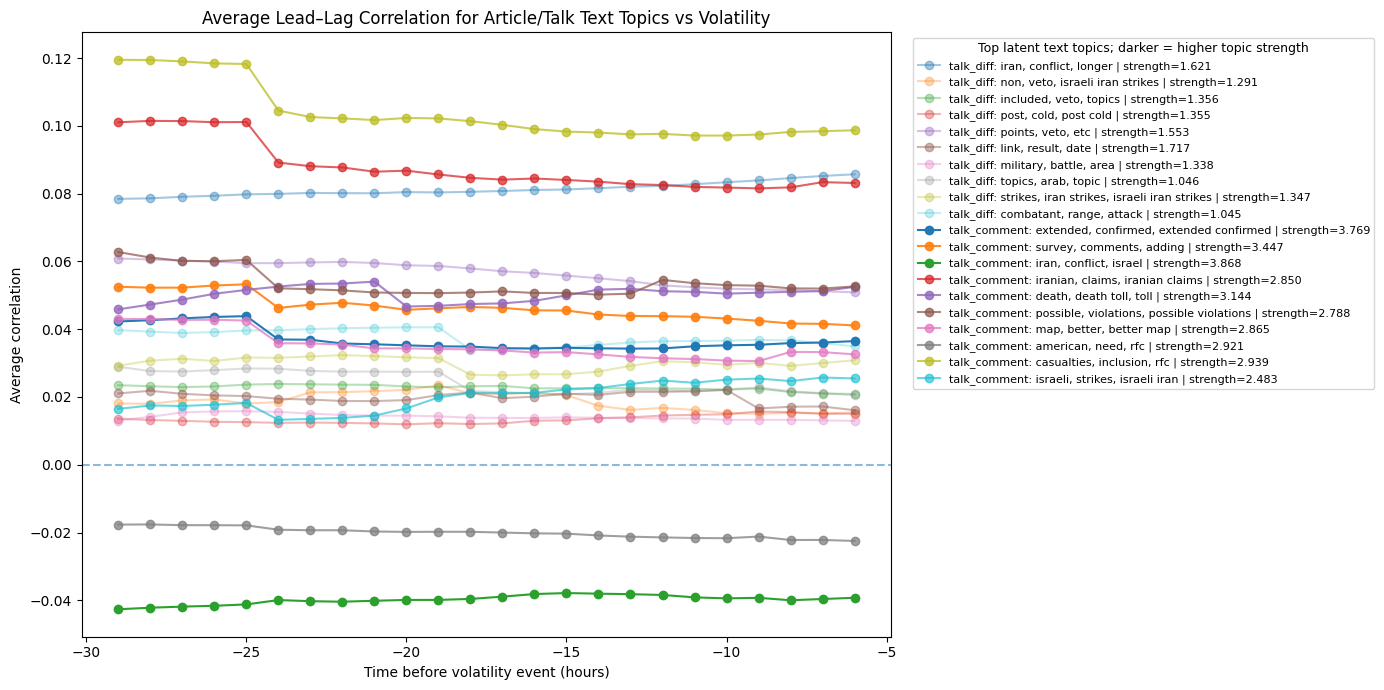

In [99]:
from utils.text.nmf import get_nmf_topic_keywords, get_nmf_topic_strengths


max_lag = 24
target_horizon = 6
time_to_event = -(np.arange(max_lag) + target_horizon)



all_strengths = np.concatenate([
    get_nmf_topic_strengths(model_obj["nmf"])
    for model_obj in text_models.values()
])

strength_min = all_strengths.min()
strength_max = all_strengths.max()

def alpha_from_strength(strength, min_alpha=0.25, max_alpha=1.0):
    """Map a topic strength to a matplotlib alpha value.

    Scales strength linearly to the [min_alpha, max_alpha] range based on
    the global strength_min and strength_max values.

    Args:
        strength (float): Topic strength to convert.
        min_alpha (float): Minimum alpha for the weakest topic.
        max_alpha (float): Maximum alpha for the strongest topic.

    Returns:
        float: Alpha value to use for plotting.
    """
    if strength_max == strength_min:
        return max_alpha
    scaled = (strength - strength_min) / (strength_max - strength_min)
    return min_alpha + scaled * (max_alpha - min_alpha)

plt.figure(figsize=(14, 7))

for model_name, model_obj in text_models.items():
    cols = model_obj["cols"]
    nmf = model_obj["nmf"]
    terms = model_obj["terms"]
    strengths = get_nmf_topic_strengths(nmf)

    for i, col in enumerate(cols):
        market_corrs = {}

        for slug, g in df.groupby("market_slug"):
            g = g.sort_values("timestamp").copy()
            target = g["price"].shift(-target_horizon)

            corrs = []
            for lag in range(max_lag):
                x = g[col].shift(lag)
                corrs.append(x.corr(target))

            market_corrs[slug] = corrs

        corr_df_temp = pd.DataFrame(market_corrs)
        avg_corr = corr_df_temp.mean(axis=1)

        label_words = ", ".join(
            get_nmf_topic_keywords(nmf, terms, i, top_n=3)["term"]
        )
        alpha = alpha_from_strength(strengths[i])

        plt.plot(
            time_to_event,
            avg_corr,
            marker="o",
            linewidth=1.5,
            alpha=alpha,
            label=f"{model_name}: {label_words} | strength={strengths[i]:.3f}"
        )

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Average Lead–Lag Correlation for Article/Talk Text Topics vs Volatility")
plt.xlabel("Time before volatility event (hours)")
plt.ylabel("Average correlation")

plt.legend(
    title="Top latent text topics; darker = higher topic strength",
    fontsize=8,
    title_fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

In [100]:

# choose channel + topic
channel = "talk_comment"   # options: article_diff, article_comment, talk_diff, talk_comment
topic_idx = 2

model_obj = text_models[channel]

nmf = model_obj["nmf"]
terms = model_obj["terms"]

pos = get_nmf_topic_keywords(
    nmf,
    terms,
    topic_idx,
    top_n=15
)

print(f"Channel: {channel}")
print(f"Topic: {topic_idx}")

print("\nPositive side:")
print(pos.to_string(index=False))

Channel: talk_comment
Topic: 2

Positive side:
         term   weight
         iran 3.444613
     conflict 1.384821
       israel 0.363736
      attacks 0.296555
       crisis 0.273961
iran conflict 0.236434
     iran_war 0.217022
     protests 0.209695
        moved 0.209205
    countries 0.180845
         lead 0.180458
   flighttime 0.155918
       attack 0.155793
  iran israel 0.143795
          rfc 0.141599


#### Kernel

In [107]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()
df = df.sort_values(["market_slug", "timestamp"]).copy()

# =====================================================
# KERNELS
# =====================================================

# short-term reaction kernel (~4–8h)
short_kernel = np.array([0, 0, 0, 0.15, 0.22, 0.26, 0.22, 0.15])

short_kernel = short_kernel / short_kernel.sum()

# long-term buildup kernel (~4–24h)
long_kernel = np.array(
    [
        0,
        0,
        0,
        0,
        0.03,
        0.04,
        0.05,
        0.06,
        0.07,
        0.08,
        0.08,
        0.08,
        0.08,
        0.07,
        0.06,
        0.05,
        0.05,
        0.04,
        0.04,
        0.03,
        0.03,
        0.02,
        0.02,
        0.02,
    ]
)

long_kernel = long_kernel / long_kernel.sum()

# =====================================================
# BUILD SIGNAL FEATURES
# =====================================================

base_cols = list(dict.fromkeys(
    text_cols + [
        "edits",
        "new_editors",
        "total_comment_len",
        "unique_editors",
        "num_seen_before_global",
        "avg_comment_len",
        "num_replies",
        "num_reverts",
        "num_escalation_comments",
        "num_uncertainty_comments",
    ]
))

signal_cols = []

for col in base_cols:

    # -----------------------------
    # SHORT SIGNAL
    # -----------------------------
    short_parts = []

    for lag, w in enumerate(short_kernel, start=1):
        short_parts.append(w * df.groupby("market_slug")[col].shift(lag))

    short_col = f"{col}_short_signal"

    df[short_col] = sum(short_parts)

    signal_cols.append(short_col)

    # -----------------------------
    # LONG SIGNAL
    # -----------------------------
    long_parts = []

    for lag, w in enumerate(long_kernel, start=1):
        long_parts.append(w * df.groupby("market_slug")[col].shift(lag))

    long_col = f"{col}_long_signal"

    df[long_col] = sum(long_parts)

    signal_cols.append(long_col)

# =====================================================
# FEATURE ENGINEERING
# =====================================================

feature_cols = signal_cols.copy()

# interaction features
for col in text_cols:

    short_interaction = f"{col}_short_x_new_editors"
    long_interaction = f"{col}_long_x_new_editors"

    df[short_interaction] = df[f"{col}_short_signal"] * df["new_editors_short_signal"]

    df[long_interaction] = df[f"{col}_long_signal"] * df["new_editors_long_signal"]

    feature_cols.append(short_interaction)
    feature_cols.append(long_interaction)

# aggregate intensity features
short_text_signals = [f"{col}_short_signal" for col in text_cols]

long_text_signals = [f"{col}_long_signal" for col in text_cols]

df["short_text_intensity"] = df[short_text_signals].abs().sum(axis=1)

df["long_text_intensity"] = df[long_text_signals].abs().sum(axis=1)

feature_cols.append("short_text_intensity")
feature_cols.append("long_text_intensity")

# =====================================================
# CLEAN MODEL FRAME
# =====================================================

model_df = pd.concat(
    [df[["market_slug", "timestamp"]], df[feature_cols], df[TARGET]], axis=1
).dropna()

model_df = model_df.sort_values("timestamp")
model_df["movement"] = (model_df[TARGET].abs() > 0).astype(int)
# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

# =====================================================
# FEATURES / TARGETS
# =====================================================

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["movement"]
y_test = test_df["movement"]

# =====================================================
# SCALE
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================
# MODEL
# =====================================================

model = LogisticRegression(
    max_iter=1000, C=0.5, penalty="l1", solver="liblinear", class_weight="balanced"
)

print("Train counts:")
print(y_train.value_counts())

print("\nTest counts:")
print(y_test.value_counts())

print("\nTrain movement rate:", y_train.mean())
print("Test movement rate:", y_test.mean())

model.fit(X_train_scaled, y_train)

# =====================================================
# EVALUATION
# =====================================================

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)

print("\nAUC:", auc)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

coef_df = pd.DataFrame({"feature": feature_cols, "coef": model.coef_[0]}).sort_values(
    "coef", ascending=False
)

print("\nTop positive:")
print(coef_df.head(15))

print("\nTop negative:")
print(coef_df.tail(15))

Train counts:
movement
0    17863
1     2075
Name: count, dtype: int64

Test counts:
movement
0    8347
1     199
Name: count, dtype: int64

Train movement rate: 0.10407262513792757
Test movement rate: 0.02328574771823075

AUC: 0.6512486356546119

Top positive:
                                  feature      coef
47             unique_editors_long_signal  2.743764
13            talk_diff_nmf_6_long_signal  0.788959
79     talk_diff_nmf_9_long_x_new_editors  0.777359
27         talk_comment_nmf_3_long_signal  0.603037
52               num_replies_short_signal  0.453215
42               new_editors_short_signal  0.409217
99  talk_comment_nmf_9_long_x_new_editors  0.365691
81  talk_comment_nmf_0_long_x_new_editors  0.308542
0            talk_diff_nmf_0_short_signal  0.305940
10           talk_diff_nmf_5_short_signal  0.256618
25         talk_comment_nmf_2_long_signal  0.246367
49     num_seen_before_global_long_signal  0.242473
11            talk_diff_nmf_5_long_signal  0.224591
9         

In [44]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5


In [45]:
shuffle_aucs = []

for seed in tqdm(range(50)):
    y_perm = y_train.sample(frac=1, random_state=seed)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train_scaled, y_perm)
    pred = m.predict_proba(X_test_scaled)[:, 1]
    shuffle_aucs.append(roc_auc_score(y_test, pred))

print("Real AUC:", auc)
print("Shuffle mean:", np.mean(shuffle_aucs))
print("Shuffle max:", np.max(shuffle_aucs))

100%|██████████| 50/50 [00:00<00:00, 52.80it/s]

Real AUC: 0.5
Shuffle mean: 0.5
Shuffle max: 0.5


#### nmf vizs

In [ ]:


# -------------------------------------------------
# SELECT TOP FEATURES
# -------------------------------------------------
top_n = 15

top_pos = coef_df.sort_values(
    "coef",
    ascending=False
).head(top_n)

top_neg = coef_df.sort_values(
    "coef",
    ascending=True
).head(top_n)

plot_df = pd.concat([
    top_neg,
    top_pos
]).drop_duplicates().copy()

plot_df = plot_df.sort_values("coef")

plot_df["label"] = plot_df["feature"].apply(
    lambda x: replace_nmf_with_keywords(
        x,
        text_models,
        top_n=3
    )
)

# -------------------------------------------------
# COLOR MAPPING
# -------------------------------------------------
coef_max = np.max(np.abs(plot_df["coef"]))

norm = mcolors.TwoSlopeNorm(
    vmin=-coef_max,
    vcenter=0,
    vmax=coef_max
)

cmap = cm.RdBu

colors = [
    cmap(norm(v))
    for v in plot_df["coef"]
]

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 10))

y_positions = np.arange(len(plot_df))

ax.barh(
    y=y_positions,
    width=plot_df["coef"],
    color=colors,
    alpha=0.9
)

# -------------------------------------------------
# REMOVE Y TICKS
# -------------------------------------------------
ax.set_yticks([])

# -------------------------------------------------
# CENTER LINE
# -------------------------------------------------
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

# -------------------------------------------------
# LABEL ANNOTATIONS
# -------------------------------------------------
label_offset = coef_max * 0.03

for y, coef, label in zip(
    y_positions,
    plot_df["coef"],
    plot_df["label"]
):

    # positive coefficients (blue bars)
    if coef > 0:
        ax.text(
            -label_offset,
            y,
            label,
            ha="right",
            va="center",
            fontsize=9
        )

    # negative coefficients (red bars)
    else:
        ax.text(
            label_offset,
            y,
            label,
            ha="left",
            va="center",
            fontsize=9
        )

# -------------------------------------------------
# TITLES
# -------------------------------------------------
ax.set_title(
    "Most Predictive Wikipedia-Derived Features\n"
    "Latent Topics Replaced with Top Keywords",
    fontsize=14
)

ax.set_xlabel(
    "Logistic regression coefficient",
    fontsize=12
)

# -------------------------------------------------
# CLEAN LOOK
# -------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"
vol_col = "volatility_6h"

smooth_window = 6
vol_quantile = 0.9

# -----------------------------
# SELECT ONE MARKET
# -----------------------------
g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

# -----------------------------
# USE EXISTING TRAINED MODEL
# -----------------------------
plot_df = g[["timestamp", vol_col] + feature_cols].dropna().copy()

X_plot = plot_df[feature_cols]
X_plot_scaled = scaler.transform(X_plot)

plot_df["pred_prob"] = model.predict_proba(X_plot_scaled)[:, 1]
plot_df["model_score"] = model.decision_function(X_plot_scaled)

# -----------------------------
# DISPLAY VOLATILITY ONLY
# -----------------------------
plot_df["vol_smooth"] = (
    plot_df[vol_col]
    .rolling(smooth_window)
    .mean()
)

# Actual top-decile volatility for visualization only
vol_threshold = plot_df["vol_smooth"].quantile(vol_quantile)
plot_df["actual_top_decile_vol"] = plot_df["vol_smooth"] > vol_threshold

plot_df = plot_df.dropna(subset=["vol_smooth"])

# -----------------------------
# NEWS EVENTS
# -----------------------------
news_events = [
    {"time": "2026-04-02 12:00:00+00:00", "label": "Trump: hit Iran 'very hard'"},
    {"time": "2026-04-05 00:00:00+00:00", "label": "US jets reportedly shot down"},
    {"time": "2026-04-07 00:00:00+00:00", "label": "Ceasefire discussions"},
]

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    plot_df["timestamp"],
    plot_df["vol_smooth"],
    color="black",
    linewidth=2,
    label="Smoothed realized 6h volatility"
)

actual_spikes = plot_df["actual_top_decile_vol"]

ax1.scatter(
    plot_df.loc[actual_spikes, "timestamp"],
    plot_df.loc[actual_spikes, "vol_smooth"],
    color="red",
    s=40,
    label="Actual top-decile volatility"
)

ax1.set_ylabel("Smoothed realized volatility")
ax1.set_xlabel("Time (UTC)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["timestamp"],
    plot_df["pred_prob"],
    color="orange",
    linewidth=2,
    label="Panel model predicted probability"
)

ax2.fill_between(
    plot_df["timestamp"],
    0,
    plot_df["pred_prob"],
    color="orange",
    alpha=0.25
)

# dynamic probability scale
pmax = plot_df["pred_prob"].max()
ax2.set_ylim(0, max(0.05, pmax * 1.0))
ax2.set_ylabel("Predicted probability")

# News event markers
for i, event in enumerate(news_events):
    t = pd.to_datetime(event["time"], utc=True)

    ax1.axvline(
        x=t,
        color="blue",
        linestyle="--",
        linewidth=1.3,
        alpha=0.65
    )

    y_frac = 0.96 if i % 2 == 0 else 0.86

    ax1.annotate(
        event["label"],
        xy=(t, y_frac),
        xycoords=("data", "axes fraction"),
        xytext=(8, 0),
        textcoords="offset points",
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
        color="blue",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="blue",
            alpha=0.75,
            linewidth=0.7
        ),
        clip_on=True,
        zorder=10
    )

plt.title(
    f"Panel Model Predictions vs Realized Volatility\n"
    f"Market: {slug}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.xlim(plot_df["timestamp"].min(), plot_df["timestamp"].max())
plt.tight_layout()
plt.show()

### Regression

#### Linear Regression

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

single_market_df = df[df["market_slug"] == MARKET].sort_values("timestamp").copy()

# Lagged TARGET features
single_market_df[f"{TARGET}_lag_1"] = single_market_df[TARGET].shift(1)
single_market_df[f"{TARGET}_lag_3"] = single_market_df[TARGET].shift(3)
single_market_df[f"{TARGET}_lag_6"] = single_market_df[TARGET].shift(6)
single_market_df[f"{TARGET}_lag_12"] = single_market_df[TARGET].shift(12)

lag_features = [
    f"{TARGET}_lag_1",
    f"{TARGET}_lag_3",
    f"{TARGET}_lag_6",
    f"{TARGET}_lag_12",
]

wiki_features = feature_cols.copy()


def run_linear_regression(feature_set, label):
    model_df = (
        single_market_df[["timestamp"] + feature_set + [TARGET]]
        .dropna()
        .sort_values("timestamp")
    )

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[TARGET]
    y_test = test_df[TARGET]

    model = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    linreg = model.named_steps["linearregression"]

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("Intercept:", linreg.intercept_)
    print("Nonzero coefficients:", np.sum(linreg.coef_ != 0))

    coef_df = pd.DataFrame(
        {
            "feature": feature_set,
            "coef": linreg.coef_,
        }
    ).sort_values("coef", ascending=False)

    print("\nTop positive coefficients:")
    print(coef_df.head(10))

    print("\nTop negative coefficients:")
    print(coef_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "coef_df": coef_df,
    }


# Model A: lagged TARGET only
result_lags = run_linear_regression(lag_features, "Model A: Lagged TARGET only")

# Model B: Wikipedia features only
result_wiki = run_linear_regression(wiki_features, "Model B: Wikipedia features only")

# Model C: lagged TARGET + Wikipedia features
result_combined = run_linear_regression(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged TARGET + Wikipedia features",
)



Model A: Lagged TARGET only
n_train: 995
n_test: 427
n_features: 4
R2: 0.5488582356512128
MAE: 0.003787946202634167
Intercept: -0.0009145728643216081
Nonzero coefficients: 4

Top positive coefficients:
             feature      coef
0   ret_fwd_6h_lag_1  0.012223
1   ret_fwd_6h_lag_3  0.001928
3  ret_fwd_6h_lag_12 -0.000702
2   ret_fwd_6h_lag_6 -0.003577

Top negative coefficients:
             feature      coef
0   ret_fwd_6h_lag_1  0.012223
1   ret_fwd_6h_lag_3  0.001928
3  ret_fwd_6h_lag_12 -0.000702
2   ret_fwd_6h_lag_6 -0.003577


KeyError: "['talk_comment_nmf_0_short_signal', 'talk_comment_nmf_0_long_signal', 'talk_comment_nmf_1_short_signal', 'talk_comment_nmf_1_long_signal', 'talk_comment_nmf_2_short_signal', 'talk_comment_nmf_2_long_signal', 'talk_comment_nmf_3_short_signal', 'talk_comment_nmf_3_long_signal', 'talk_comment_nmf_4_short_signal', 'talk_comment_nmf_4_long_signal', 'talk_comment_nmf_5_short_signal', 'talk_comment_nmf_5_long_signal', 'talk_comment_nmf_6_short_signal', 'talk_comment_nmf_6_long_signal', 'talk_comment_nmf_7_short_signal', 'talk_comment_nmf_7_long_signal', 'talk_comment_nmf_8_short_signal', 'talk_comment_nmf_8_long_signal', 'talk_comment_nmf_9_short_signal', 'talk_comment_nmf_9_long_signal', 'talk_comment_nmf_0_short_x_new_editors', 'talk_comment_nmf_0_long_x_new_editors', 'talk_comment_nmf_1_short_x_new_editors', 'talk_comment_nmf_1_long_x_new_editors', 'talk_comment_nmf_2_short_x_new_editors', 'talk_comment_nmf_2_long_x_new_editors', 'talk_comment_nmf_3_short_x_new_editors', 'talk_c

#### ElasticNetCV

In [82]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

single_market_df = df[df["market_slug"] == MARKET].sort_values("timestamp").copy()

# Lagged TARGET features
single_market_df[f"{TARGET}_lag_1"] = single_market_df[TARGET].shift(1)
single_market_df[f"{TARGET}_lag_3"] = single_market_df[TARGET].shift(3)
single_market_df[f"{TARGET}_lag_6"] = single_market_df[TARGET].shift(6)
single_market_df[f"{TARGET}_lag_12"] = single_market_df[TARGET].shift(12)

lag_features = [
    f"{TARGET}_lag_1",
    f"{TARGET}_lag_3",
    f"{TARGET}_lag_6",
    f"{TARGET}_lag_12",
]

wiki_features = feature_cols.copy()


def run_elasticnet(feature_set, label):
    model_df = (
        single_market_df[["timestamp"] + feature_set + [TARGET]]
        .dropna()
        .sort_values("timestamp")
    )

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[TARGET]**2
    y_test = test_df[TARGET]**2

    tscv = TimeSeriesSplit(n_splits=5)

    model = make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            l1_ratio=[0.001, 0.01, 0.05, 0.1, 0.5, 0.9],
            alphas=np.logspace(-6, 0, 80),
            cv=tscv,
            max_iter=100000,
            tol=1e-5,
            selection="random",
            random_state=42,
        ),
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elasticnet = model.named_steps["elasticnetcv"]

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("Best alpha:", elasticnet.alpha_)
    print("Best l1_ratio:", elasticnet.l1_ratio_)
    print("Nonzero coefficients:", np.sum(elasticnet.coef_ != 0))

    coef_df = pd.DataFrame(
        {
            "feature": feature_set,
            "coef": elasticnet.coef_,
        }
    ).sort_values("coef", ascending=False)

    print("\nTop positive coefficients:")
    print(coef_df.head(10))

    print("\nTop negative coefficients:")
    print(coef_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "coef_df": coef_df,
    }


# Model A: lagged TARGET only
result_lags = run_elasticnet(lag_features, "Model A: Lagged TARGET only")

# Model B: Wikipedia features only
result_wiki = run_elasticnet(wiki_features, "Model B: Wikipedia features only")

# Model C: lagged TARGET + Wikipedia features
result_combined = run_elasticnet(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged TARGET + Wikipedia features",
)


Model A: Lagged TARGET only
n_train: 995
n_test: 427
n_features: 4
R2: -0.0237131082173625
MAE: 0.00036610499805820674
Best alpha: 1.0
Best l1_ratio: 0.001
Nonzero coefficients: 0

Top positive coefficients:
             feature  coef
0   ret_fwd_6h_lag_1  -0.0
1   ret_fwd_6h_lag_3  -0.0
2   ret_fwd_6h_lag_6   0.0
3  ret_fwd_6h_lag_12   0.0

Top negative coefficients:
             feature  coef
0   ret_fwd_6h_lag_1  -0.0
1   ret_fwd_6h_lag_3  -0.0
2   ret_fwd_6h_lag_6   0.0
3  ret_fwd_6h_lag_12   0.0


/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.601e-09, tolerance: 2.193e-10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.044e-10, tolerance: 2.193e-10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di


Model B: Wikipedia features only
n_train: 986
n_test: 424
n_features: 48
R2: -0.02460141919233183
MAE: 0.00036978453059818595
Best alpha: 0.00038218926206331187
Best l1_ratio: 0.5
Nonzero coefficients: 0

Top positive coefficients:
                                   feature  coef
0          talk_comment_nmf_0_short_signal  -0.0
1           talk_comment_nmf_0_long_signal   0.0
26  talk_comment_nmf_0_short_x_new_editors   0.0
27   talk_comment_nmf_0_long_x_new_editors   0.0
28  talk_comment_nmf_1_short_x_new_editors   0.0
29   talk_comment_nmf_1_long_x_new_editors  -0.0
30  talk_comment_nmf_2_short_x_new_editors   0.0
31   talk_comment_nmf_2_long_x_new_editors  -0.0
32  talk_comment_nmf_3_short_x_new_editors  -0.0
33   talk_comment_nmf_3_long_x_new_editors   0.0

Top negative coefficients:
                            feature  coef
13   talk_comment_nmf_6_long_signal   0.0
14  talk_comment_nmf_7_short_signal  -0.0
15   talk_comment_nmf_7_long_signal  -0.0
16  talk_comment_nmf_8_short_sig

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.248e-10, tolerance: 2.193e-10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.443e-10, tolerance: 2.193e-10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di


Model C: Lagged TARGET + Wikipedia features
n_train: 986
n_test: 424
n_features: 52
R2: -0.02460141919233183
MAE: 0.00036978453059818595
Best alpha: 0.00022616759492228645
Best l1_ratio: 0.9
Nonzero coefficients: 0

Top positive coefficients:
                                   feature  coef
0                         ret_fwd_6h_lag_1  -0.0
1                         ret_fwd_6h_lag_3  -0.0
28          total_comment_len_short_signal   0.0
29           total_comment_len_long_signal  -0.0
30  talk_comment_nmf_0_short_x_new_editors  -0.0
31   talk_comment_nmf_0_long_x_new_editors   0.0
32  talk_comment_nmf_1_short_x_new_editors  -0.0
33   talk_comment_nmf_1_long_x_new_editors   0.0
34  talk_comment_nmf_2_short_x_new_editors   0.0
35   talk_comment_nmf_2_long_x_new_editors  -0.0

Top negative coefficients:
                            feature  coef
15   talk_comment_nmf_5_long_signal  -0.0
16  talk_comment_nmf_6_short_signal  -0.0
17   talk_comment_nmf_6_long_signal  -0.0
18  talk_comment_nmf_

#### Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd


single_market_df = (
    df[df["market_slug"] == MARKET]
    .sort_values("timestamp")
    .copy()
)

# Lagged TARGET features
single_market_df[f"{TARGET}_lag_1"] = single_market_df[TARGET].shift(1)
single_market_df[f"{TARGET}_lag_3"] = single_market_df[TARGET].shift(3)
single_market_df[f"{TARGET}_lag_6"] = single_market_df[TARGET].shift(6)
single_market_df[f"{TARGET}_lag_12"] = single_market_df[TARGET].shift(12)

lag_features = [
    f"{TARGET}_lag_1",
    f"{TARGET}_lag_3",
    f"{TARGET}_lag_6",
    f"{TARGET}_lag_12",
]

wiki_features = feature_cols.copy()

def run_random_forest(feature_set, label):
    model_df = single_market_df[
        ["timestamp"] + feature_set + [TARGET]
    ].dropna().sort_values("timestamp")

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[TARGET]
    y_test = test_df[TARGET]

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))

    importance_df = pd.DataFrame({
        "feature": feature_set,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    print("\nTop feature importances:")
    print(importance_df.head(10))

    print("\nLeast important features:")
    print(importance_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "importance_df": importance_df,
    }


# Model A: lagged TARGET only
result_lags = run_random_forest(
    lag_features,
    "Model A: Lagged TARGET only"
)

# Model B: Wikipedia features only
result_wiki = run_random_forest(
    wiki_features,
    "Model B: Wikipedia features only"
)

# Model C: lagged TARGET + Wikipedia features
result_combined = run_random_forest(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged TARGET + Wikipedia features"
)



Model A: Lagged TARGET only
n_train: 997
n_test: 428
n_features: 4
R2: 0.36995608447184514
MAE: 0.0035709769242151263

Top feature importances:
             feature  importance
0   ret_fwd_3h_lag_1    0.820514
1   ret_fwd_3h_lag_3    0.095591
2   ret_fwd_3h_lag_6    0.046213
3  ret_fwd_3h_lag_12    0.037682

Least important features:
             feature  importance
0   ret_fwd_3h_lag_1    0.820514
1   ret_fwd_3h_lag_3    0.095591
2   ret_fwd_3h_lag_6    0.046213
3  ret_fwd_3h_lag_12    0.037682

Model B: Wikipedia features only
n_train: 989
n_test: 424
n_features: 48
R2: -0.002081299276220472
MAE: 0.004119115726150623

Top feature importances:
                                  feature  importance
47                    long_text_intensity    0.049372
21                      edits_long_signal    0.048834
25          total_comment_len_long_signal    0.046237
46                   short_text_intensity    0.043650
9          talk_comment_nmf_4_long_signal    0.043538
24         total_comme

#### ARIMA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# CONFIG
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"
vol_col = "volatility_6h"

# -----------------------------
# SELECT ONE MARKET
# -----------------------------
g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

# -----------------------------
# BUILD TIME SERIES
# -----------------------------
y = (
    g[["timestamp", vol_col]]
    .dropna()
    .set_index("timestamp")[vol_col]
)

# optional: stabilize volatility
y = np.log(y + 1e-6)

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
split = int(len(y) * 0.7)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# -----------------------------
# FIT ARIMA BASELINE
# -----------------------------
# Start with ARIMA(1,0,1): ARMA-style volatility persistence model
arima = ARIMA(
    y_train,
    order=(1, 0, 1)
)

res = arima.fit()

print(res.summary())

# -----------------------------
# FORECAST TEST PERIOD
# -----------------------------
forecast = res.forecast(steps=len(y_test))

# align index
forecast.index = y_test.index

# -----------------------------
# EVALUATE
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae = mean_absolute_error(y_test, forecast)

print("\nARIMA baseline:")
print("RMSE:", rmse)
print("MAE:", mae)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    y_train.index,
    y_train,
    label="Train log volatility",
    alpha=0.7
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual test log volatility",
    color="black",
    linewidth=2
)

plt.plot(
    forecast.index,
    forecast,
    label="ARIMA forecast",
    color="orange",
    linewidth=2
)

plt.axvline(
    y_test.index.min(),
    linestyle="--",
    color="gray",
    label="Train/test split"
)

plt.title(f"ARIMA Baseline Forecast for Log Volatility\nMarket: {slug}")
plt.xlabel("Time")
plt.ylabel("Log 6h volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### SARIMAX

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
slug = "will-the-us-invade-iran-before-2027"

target_col = "price"

selected_features = [
    "edits_long_signal",
]

# -------------------------------------------------
# SELECT MARKET
# -------------------------------------------------
g = df[df["market_slug"] == slug].sort_values("timestamp").copy()

# -------------------------------------------------
# BUILD DATASET
# -------------------------------------------------
model_df = g[["timestamp", vol_col] + selected_features].dropna()

model_df = model_df.set_index("timestamp")

# optional stabilization
model_df["log_vol"] = np.log(model_df[vol_col] + 1e-6)

# -------------------------------------------------
# TARGET / EXOGENOUS
# -------------------------------------------------
y = model_df["log_vol"]

X = model_df[selected_features]

# -------------------------------------------------
# TRAIN / TEST SPLIT
# -------------------------------------------------
split = int(len(model_df) * 0.7)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

X_train = X.iloc[:split]
X_test = X.iloc[split:]

# -------------------------------------------------
# FIT SARIMAX
# -------------------------------------------------
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    # ARIMA(1,0,1)
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results = model.fit(disp=False)

print(results.summary())

# -------------------------------------------------
# FORECAST
# -------------------------------------------------
forecast = results.forecast(steps=len(y_test), exog=X_test)

forecast.index = y_test.index

# -------------------------------------------------
# EVALUATE
# -------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, forecast))

mae = mean_absolute_error(y_test, forecast)

print("\nSARIMAX Results")
print("RMSE:", rmse)
print("MAE:", mae)

# -------------------------------------------------
# PLOT
# -------------------------------------------------
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, alpha=0.5, label="Train log volatility")

plt.plot(
    y_test.index, y_test, color="black", linewidth=2, label="Actual test log volatility"
)

plt.plot(
    forecast.index, forecast, color="orange", linewidth=2, label="SARIMAX forecast"
)

plt.axvline(y_test.index.min(), linestyle="--", color="gray", alpha=0.7)

plt.title(f"SARIMAX Forecast with Wikipedia Signals\n{slug}")

plt.xlabel("Time")
plt.ylabel("Log volatility")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'vol_col' is not defined